# <center> Machine Learning in Computational Biology - Assignment #1</center>
### <center>*Spring 2026*</center>
### <center>*Epigenetic Age Prediction from DNA Methylation*</center>

---


### Libraries

In [1]:
import sys
import os
from importlib.metadata import metadata

sys.path.append(os.path.abspath("../src"))
import pandas as pd
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix
import numpy as np
#sklearn
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from functions import *
print("Libraries successfully loaded")

Libraries successfully loaded


# Task 1 : Data Loading and Preprocessing
---

## 1.1 Data splitting
<!-- Load development_data.csv and split it into an internal 80% training / 20% validation split -->
<!--(stratified by age, seed=42). Load evaluation_data.csv separately and treat it as locked — it-->
<!--must not influence any design decision.-->


In [2]:
# Loading the data
dev_data = pd.read_csv("../data/development_data.csv", index_col=0)
print("Development set", dev_data.shape, dev_data.head())
print("\n")
eval_data=pd.read_csv("../data/evaluation_data.csv", index_col=0)
print("Evaluation set (locked)", eval_data.shape,eval_data.head())
print(len(dev_data),len(eval_data))

Development set (456, 1003)            age             ethnicity sex  cg16867657  cg06639320  cg24724428  \
sample_id                                                                      
GSM990554   79  Caucasian - European   M    0.672001    0.504461    0.331257   
GSM990278   46    Hispanic - Mexican   M    0.555411    0.389214    0.160708   
GSM990589   78  Caucasian - European   M    0.781318    0.554360    0.337578   
GSM990323   46    Hispanic - Mexican   F    0.542491    0.435584    0.228723   
GSM990116   59    Hispanic - Mexican   F    0.653190    0.466217    0.208453   

           cg07553761  cg22454769  cg06784991  cg21572722  ...  cg17321954  \
sample_id                                                  ...               
GSM990554    0.327287    0.572867    0.309496    0.444902  ...    0.174936   
GSM990278    0.230875    0.464971    0.223665    0.381837  ...    0.154691   
GSM990589    0.437668    0.645529    0.309615    0.505999  ...    0.213999   
GSM990323    0.231709

In [3]:
#Splitting the data into training and validation sets
#stratifying by age
X=dev_data
y=dev_data["age"]
y_bins=pd.qcut(y,5,duplicates='drop')

# Split the data
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42,stratify=y_bins)
total_data=len(X_train) + len(X_val)
train_pre= len(X_train)/ total_data*100
val_pre= len(X_val)/ total_data*100
print(total_data)
print(f"Training set: {len(X_train)} samples ({train_pre:.2f}%)")
print(f"Validation set : {len(X_val)} samples ({val_pre:.2f}%)")


456
Training set: 364 samples (79.82%)
Validation set : 92 samples (20.18%)


In [4]:
#Creating table of the data split information for better visualization
table_summary = pd.DataFrame({
    "Split": ["Train", "Validation"],
    "Samples": [len(X_train), len(X_val)],
    "Percentage": [train_pre, val_pre]
})
table_summary

,Split,Samples,Percentage
0,Train,364,79.824561
1,Validation,92,20.175439


## 1.2  Preprocessing

#### Checking missing values in train, val & eval sets

In [5]:
#Searching for the NA values in each data set
print("Missing values in development set")
check_missing_values(dev_data)
print("Missing values in TRAIN set")
check_missing_values(X_train)
print("Missing values in VALIDATION set")
check_missing_values(X_val)
print("Missing values in EVALUATION set")
check_missing_values(eval_data)




Missing values in development set
Total missing: 13712

Top five missing: cg26330518    32
cg25410668    28
cg15903032    25
cg01493685    25
cg12233363    25
dtype: int64
Missing values in TRAIN set
Total missing: 10965

Top five missing: cg26330518    26
cg04193015    24
cg12233363    22
cg27314669    21
cg07234388    20
dtype: int64
Missing values in VALIDATION set
Total missing: 2747

Top five missing: cg01493685    9
cg07539927    8
cg03236802    8
cg15903032    8
cg25410668    8
dtype: int64
Missing values in EVALUATION set
Total missing: 3058

Top five missing: cg12233363    10
cg10979567     9
cg11419186     9
cg03013070     9
cg10891482     9
dtype: int64


In [6]:
# Gathering feature groups
metadata,cpg,age=feature_gather(dev_data)
print("Metadata info:",metadata)
print("Info of CpG columns:",len(cpg))
print("Column of focus:",age)
print("=====================")
#Create feature sets
metadata_features = feature_set(dev_data, sets="metadata")
cpg_features = feature_set(dev_data, sets="cpg")
all_features = feature_set(dev_data, sets="all")
print("Metadata feature count:", len(metadata_features))
print("CpG feature count:", len(cpg_features))
print("All feature count:", len(all_features))

Metadata info: ['sex', 'ethnicity']
Info of CpG columns: 1000
Column of focus: age
Metadata feature count: 2
CpG feature count: 1000
All feature count: 1002


## Feature Matrices

#### _CpG feature focus_

In [7]:
# CpG feature matrix
X_train_cpg, y_train = split_feature(X_train, cpg_features, age="age")
X_val_cpg, y_val = split_feature(X_val, cpg_features, age="age")
X_eval_cpg, y_eval = split_feature(eval_data, cpg_features, age="age")

print("CpG matrix:")
print("Train_cpg:", X_train_cpg.shape)
print("Val_cpg:", X_val_cpg.shape)
print("Eval_cpg:", X_eval_cpg.shape)

print("==================================================")
#CpG preprocessing
preprocessor_cpg = preprocessor_pipeline(cpg=cpg_features, metadata=[])
X_train_cpg_processed = preprocessor_cpg.fit_transform(X_train_cpg) #only training fitting
X_val_cpg_processed = preprocessor_cpg.transform(X_val_cpg)
X_eval_cpg_processed = preprocessor_cpg.transform(X_eval_cpg)
print("Processed CpG-only")


CpG matrix:
Train_cpg: (364, 1000)
Val_cpg: (92, 1000)
Eval_cpg: (100, 1000)
Processed CpG-only


#### _Metadata feature focus_

In [8]:
#Creating a feature matrix
X_train_meta,y_train=split_feature(X_train,metadata_features,age="age")
X_val_meta,y_val=split_feature(X_val,metadata_features,age="age")
X_eval_meta,y_eval=split_feature(eval_data,metadata_features,age="age")
print("Metadata matrix:")
print("Train_metadata:", X_train_meta.shape)
print("Val_metadata:", X_val_meta.shape)
#print("Eval_meta:", X_eval_meta.shape)

print("==================================================")
#Metadata preprocessing
preprocessor_meta = preprocessor_pipeline(cpg=[], metadata=metadata_features)
X_train_meta_processed = preprocessor_meta.fit_transform(X_train_meta) #only on to be fitted
X_val_meta_processed = preprocessor_meta.transform(X_val_meta)
X_eval_meta_processed = preprocessor_meta.transform(X_eval_meta)

print("Processed Metadata matrix:")
print("Train_metadata_processed:", X_train_meta_processed.shape)
print("Val_metadata_processed:", X_val_meta_processed.shape)
print("Eval_meta_processed:", X_eval_meta_processed.shape)


Metadata matrix:
Train_metadata: (364, 2)
Val_metadata: (92, 2)
Processed Metadata matrix:
Train_metadata_processed: (364, 4)
Val_metadata_processed: (92, 4)
Eval_meta_processed: (100, 4)


### All feature matrix

In [9]:
X_train_all, y_train = split_feature(X_train, all_features, age="age")
X_val_all, y_val = split_feature(X_val, all_features, age="age")
X_eval_all, y_eval = split_feature(eval_data,all_features, age="age")

print("All features matrices:")
print("Train_all:", X_train_all.shape)
print("Val_all:", X_val_all.shape)
print("Eval_all:", X_eval_all.shape)
print("==================================================")
#All feature preprocessing together
preprocessor_all = preprocessor_pipeline(cpg=cpg_features, metadata=metadata_features)
X_train_all_processed = preprocessor_all.fit_transform(X_train_all) #fit only here
X_val_all_processed = preprocessor_all.transform(X_val_all)
X_eval_all_processed = preprocessor_all.transform(X_eval_all)
print("Processed all feature matrices:")
print("Train_all_processed:", X_train_all_processed.shape)
print("Val_all_processed:", X_val_all_processed.shape)
print("Eval_all_processed:", X_eval_all_processed.shape)



All features matrices:
Train_all: (364, 1002)
Val_all: (92, 1002)
Eval_all: (100, 1002)
Processed all feature matrices:
Train_all_processed: (364, 1004)
Val_all_processed: (92, 1004)
Eval_all_processed: (100, 1004)


## Exploratory Analysis

In [10]:
statistics_df = stats_table(X_train,X_val,eval_data)
statistics_df

,split,n_samples,age_mean ± std,age_range,Male,Female
0,Train,364,64.5 ± 14.6,19 - 101,191,173
1,Validation,92,64.2 ± 14.7,25 - 89,41,51
2,Evaluation,100,62.5 ± 14.3,21 - 92,42,58


In [11]:
#A more informative data table of the distributions of each feature and result of missing values
train_summary = data_summary(X_train, "Train")
val_summary = data_summary(X_val, "Validation")
eval_summary = data_summary(eval_data, "Evaluation")
summary_df = pd.DataFrame([train_summary, val_summary, eval_summary])
summary_df

,dataset,samples,age_mean,age_std,age_min,age_max,sex_balance,ethnicity_balance,cpg_info,total_missing_values
0,Train,364,64.51,14.64,19,101,"{'M': 191, 'F': 173}","{'Caucasian - European': 246, 'Hispanic - Mexi...",1000,10965
1,Validation,92,64.22,14.69,25,89,"{'F': 51, 'M': 41}","{'Caucasian - European': 62, 'Hispanic - Mexic...",1000,2747
2,Evaluation,100,62.50,14.35,21,92,"{'F': 58, 'M': 42}","{'Caucasian - European': 56, 'Hispanic - Mexic...",1000,3058


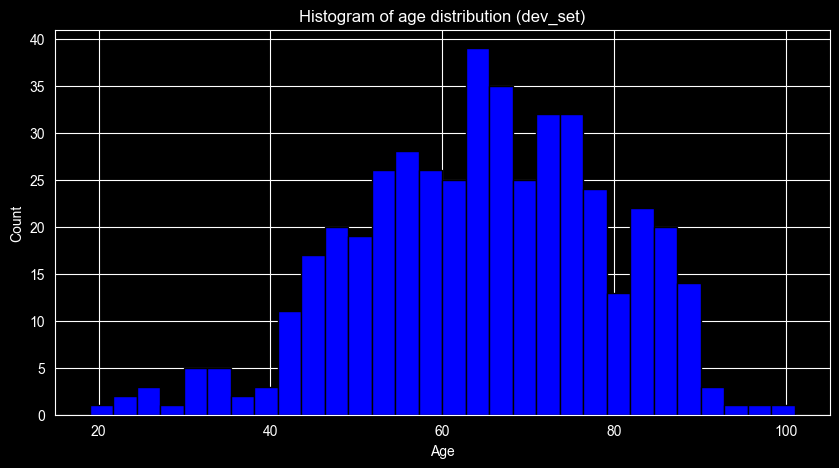

In [12]:
age_distribution_plot(dev_data["age"])

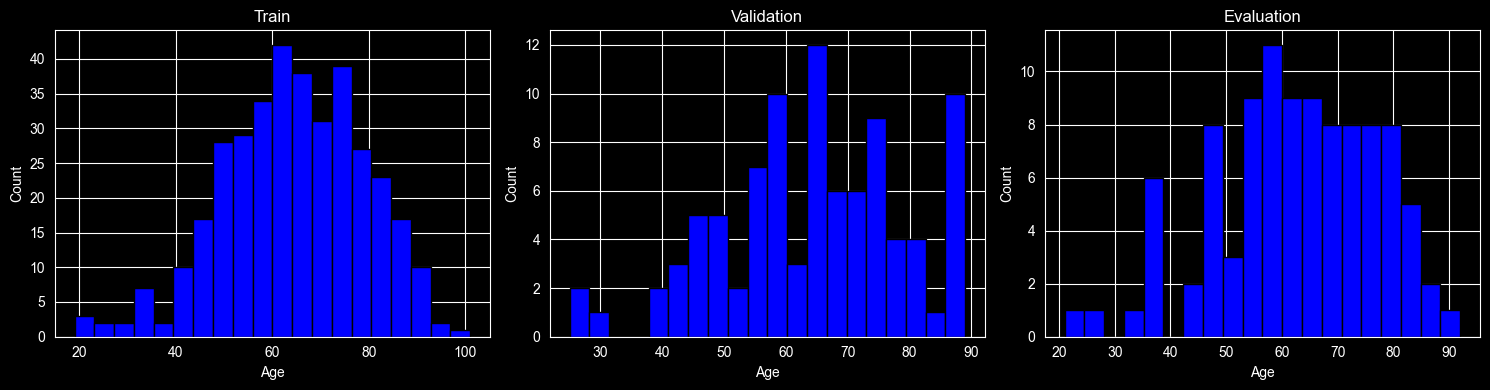

In [13]:
age_split_plot(X_train,X_val,eval_data)

---

# Task 2: Baseline Models

#### Metadata


In [15]:
ols_meta_model,ols_meta_predict=ols_model(X_train_meta_processed,y_train,X_val_meta_processed)
ols_meta_results=evaluation_of_model(y_val,ols_meta_predict)

Evaluation of the model by using bootstrap
Validation metrics and 95% CI:
RMSE: 12.9545 (95% CI: 10.3478 - 14.9251)
MAE: 9.8540 (95% CI: 8.2050 - 11.5031)
R^2: 0.2138 (95% CI: 0.0706 - 0.3744)
Pearson r: 0.4629 (95% CI: 0.3346 - 0.6314)


#### CpG feature

In [17]:
ols_cpg_model, ols_cpg_predict = ols_model(X_train_cpg_processed,y_train,X_val_cpg_processed)
ols_cpg_results = evaluation_of_model(y_val,ols_cpg_predict)

Evaluation of the model by using bootstrap
Validation metrics and 95% CI:
RMSE: 5.2543 (95% CI: 4.2169 - 6.3337)
MAE: 3.9995 (95% CI: 3.3575 - 4.5124)
R^2: 0.8707 (95% CI: 0.8087 - 0.9174)
Pearson r: 0.9360 (95% CI: 0.9039 - 0.9616)


### All features

In [18]:
ols_all_model, ols_all_predict = ols_model(X_train_all_processed,y_train,X_val_all_processed)
ols_all_results = evaluation_of_model(y_val, ols_all_predict)

Evaluation of the model by using bootstrap
Validation metrics and 95% CI:
RMSE: 5.2408 (95% CI: 4.1911 - 6.3282)
MAE: 3.9903 (95% CI: 3.3711 - 4.5128)
R^2: 0.8713 (95% CI: 0.8094 - 0.9181)
Pearson r: 0.9364 (95% CI: 0.9041 - 0.9620)
